# 04 · 방법 3 — 몬테카를로 기초: 경로를 만들어 달성 확률을 센다

[![Colab에서 열기](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/keerhee/pension-fund-strategy-and-performance/blob/main/W06_LDI%EC%99%80GBI/W06_M8_%EC%8B%A4%EC%8A%B5_Colab/04_%EB%B0%A9%EB%B2%953_%EB%AA%AC%ED%85%8C%EC%B9%B4%EB%A5%BC%EB%A1%9C_%EA%B8%B0%EC%B4%88.ipynb)

**W06 M8 GBI 강의본 42~46장과 54장 예 ③** 을 재현합니다. 같은 문제(55세 · 10억 · 세 목표 · 10년)를 이번엔 식이 아니라 **경로를 세어** 풉니다.

| 단계 | 강의 | 이 노트북에서 |
|---|---|---|
| 원리 · 정확도 | 42장 | 표준오차 √(p(1−p)/N): N 10,000 → ±0.46%p, 100,000 → ±0.14%p |
| 절차 | 43장 | 가정 → 경로 → 규칙 → 집계 → K 찾기 → 검증 |
| 경로 하나를 한 해씩 | 44장 | seed 2026 경로 1: 주식 −9.4 · +11.4 · −27.3%, 고정 비중 67% 표와 CPPI 표 |
| K 찾기 장난감 예 | 45장 | 경로 10개 · K 2.0 / 2.2 / 2.4 → 6 · 8 · 8/10 → 2.2억, 100,000 경로 2.26억 |
| 다수결은 틀린다 | 46장 | 경로마다 최적을 고르면 주식 100% · GHP 100%로 갈린다 |
| 공통 난수 | 54장 예 ③ | 1만 경로 묶음 A/B: K 2.26억 70.63 vs 69.90% |

**실행 시간** — 기본(강의 재현) 모드 10초 안팎. `FAST = True`면 경로 20,000개로 더 빠르게(확인은 표시만).

### 0. 준비 — 이 셀부터 실행
한글 폰트(Colab은 나눔고딕 설치, 맥은 Pretendard), 강의 색(잉크 · 라임 · 티일 · 빨강), 강의본 숫자 확인 함수 `check()`를 준비합니다.
`check(이름, 계산값, 강의값, 허용오차)`는 계산이 강의본 숫자와 허용오차 안에서 맞는지 확인하고, 틀리면 멈춥니다(`assert`).
`FAST = True`로 바꾸면 경로 수를 줄여 빨리 돌고, 이때 확인은 표시만 합니다.

In [1]:
# ── 환경 준비: 한글 폰트 · 강의 색 · 확인 함수 (이 셀을 먼저 실행) ──
import sys, os, glob, math, time, subprocess
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import font_manager as fm

import warnings
warnings.filterwarnings("ignore", message=".*encountered in matmul")   # 맥 numpy(Accelerate)의 거짓 경고 — 결과와 무관
IN_COLAB = "google.colab" in sys.modules
if IN_COLAB and not glob.glob("/usr/share/fonts/truetype/nanum/NanumGothic*.ttf"):
    # Colab: 나눔 폰트 설치 (= !apt-get -qq install -y fonts-nanum) — 처음 한 번 10초 안팎
    subprocess.run("apt-get -qq install -y fonts-nanum > /dev/null", shell=True)

def setup_korean_font():
    """로컬 맥은 Pretendard, Colab은 나눔고딕을 matplotlib에 등록한다(폰트 캐시 갱신과 같은 효과)."""
    files = (glob.glob(os.path.expanduser("~/Library/Fonts/Pretendard-*.otf"))
             + glob.glob("/Library/Fonts/Pretendard-*.otf")
             + glob.glob("/usr/share/fonts/truetype/nanum/NanumGothic*.ttf"))
    for f in files:
        try:
            fm.fontManager.addfont(f)
        except Exception:
            pass
    names = {f.name for f in fm.fontManager.ttflist}
    for fam in ["Pretendard", "NanumGothic", "AppleGothic", "Malgun Gothic", "Noto Sans CJK KR"]:
        if fam in names:
            plt.rcParams["font.family"] = fam
            return fam
    return "(한글 폰트 없음 — 그래프 글자가 네모로 보이면 이 셀을 다시 실행)"

FONT = setup_korean_font()
plt.rcParams["axes.unicode_minus"] = False

# 강의 색 — 잉크 · 라임 · 티일 · 빨강 (+ 보조 회색 · 아이보리 바탕)
INK, LIME, TEAL, RED = "#071A1D", "#B7F34A", "#0B6B68", "#C00000"
GRAY, IVORY, OLIVE = "#8A9496", "#F7F5F0", "#5E8C1A"
plt.rcParams.update({
    "figure.figsize": (8, 4.5), "figure.dpi": 110, "savefig.dpi": 110,
    "figure.facecolor": "white", "axes.facecolor": IVORY,
    "axes.edgecolor": INK, "axes.labelcolor": INK, "xtick.color": INK, "ytick.color": INK,
    "axes.titleweight": "bold", "axes.titlesize": 13, "axes.titlelocation": "left",
    "axes.grid": True, "grid.color": "#DDD8CC", "grid.linewidth": 0.6,
    "axes.spines.top": False, "axes.spines.right": False,
    "legend.frameon": False, "axes.axisbelow": True,
    "axes.prop_cycle": matplotlib.cycler(color=[TEAL, INK, RED, OLIVE, GRAY]),
})

# 빠른 모드 — True면 경로 · 표본 수를 줄여 빨리 끝난다(숫자가 강의와 소수 둘째 자리쯤 달라질 수 있어 확인은 표시만 한다)
FAST = False

CHECKS = []
def check(label, value, lecture, tol, fmt=".4f", unit=""):
    """계산값을 강의본 숫자와 비교한다. 기본(재현) 모드에서는 허용오차를 넘으면 멈춘다(assert)."""
    ok = abs(value - lecture) <= tol + 1e-9      # 허용오차는 보통 강의 표기 자릿수의 반(반올림하면 같은 값)
    CHECKS.append((label, ok))
    print(f"{'✓' if ok else '✗'} {label}: 계산 {value:{fmt}}{unit} · 강의 {lecture:{fmt}}{unit} (허용 ±{tol:g})")
    if not FAST:
        assert ok, f"{label}: 계산 {value} · 강의 {lecture}"

print(f"Colab: {IN_COLAB} · 그래프 폰트: {FONT} · numpy {np.__version__} · matplotlib {matplotlib.__version__}")

Colab: False · 그래프 폰트: Pretendard · numpy 2.0.2 · matplotlib 3.9.4


## 1. 원리와 정확도 (강의 42장)
**목표에 닿은 경로의 비율 = 달성 확률.** 경로 N개로 센 비율의 표준오차는 √(p(1 − p)/N).
p = 70%에서 N = 10,000이면 ±0.46%p, 강의 실행 N = 100,000이면 ±0.14%p.

In [2]:
se = lambda p, n: math.sqrt(p * (1 - p) / n)
for n in (10_000, 100_000):
    print(f"N = {n:>7,}: 표준오차 = √(0.7 × 0.3 ÷ {n:,}) = ±{100 * se(0.7, n):.2f}%p")
check("표준오차 N 10,000 (%p)", 100 * se(0.7, 10_000), 0.46, 0.005, ".2f")
check("표준오차 N 100,000 (%p)", 100 * se(0.7, 100_000), 0.14, 0.005, ".2f")

N =  10,000: 표준오차 = √(0.7 × 0.3 ÷ 10,000) = ±0.46%p
N = 100,000: 표준오차 = √(0.7 × 0.3 ÷ 100,000) = ±0.14%p
✓ 표준오차 N 10,000 (%p): 계산 0.46 · 강의 0.46 (허용 ±0.005)
✓ 표준오차 N 100,000 (%p): 계산 0.14 · 강의 0.14 (허용 ±0.005)


## 2. 가정과 경로 만들기 (강의 43장 ①②)
- GHP: 실질 r = 2% → 연 수익률 e^0.02 − 1 = 2.02%, 변동성 0
- 주식: 연 로그수익 = r + λ − ½σ² + σ·ε (λ 6%, σ 20%, ε ~ 표준정규) → 연 수익률 R = e^(로그수익) − 1
- 난수 시드 2026, 경로 100,000개 × 10년 — **경로는 한 번만 만들고 모든 후보에 다시 씁니다(공통 난수).**

In [3]:
SEED, T = 2026, 10
N = 20_000 if FAST else 100_000
r, lam, sig = 0.02, 0.06, 0.20
RG = math.exp(r) - 1
W_MARKET = 0.6708            # Market 주식 비중(강의 스크립트 gbi_mc.py와 같은 값)

def stock_returns(rng, n):
    """연 주식 수익률 R (n 경로 × T년)"""
    e = rng.standard_normal((n, T))
    return np.exp(r + lam - 0.5 * sig * sig + sig * e) - 1

t0 = time.time()
R = stock_returns(np.random.default_rng(SEED), N)
print(f"경로 {N:,}개 × {T}년 · {time.time() - t0:.2f}초 · 연 수익률 평균 {R.mean():.2%} · 표준편차 {R.std():.2%}")

경로 100,000개 × 10년 · 0.02초 · 연 수익률 평균 8.33% · 표준편차 21.90%


## 3. 규칙을 경로에 적용 = 경로 하나를 한 해씩 굴린다 (강의 44장)
**고정 비중** — 해마다 연초에 주식 w · GHP 1 − w로 되돌리고 그 해 수익을 반영: W(t+1) = W(t) × [w(1 + R) + (1 − w)(1 + 2.02%)]

**CPPI** — ① floor F(t) = 목표의 현재가치 G·e^(−r(T − t)) ② 쿠션 C = W − F ③ 노출 E = m·C(0과 W 사이로 자름) ④ 나머지는 GHP ⑤ 한 해 수익 반영

강의 표: Market 몫 2.24억(w 67%)의 고정 비중, 그리고 10억 · floor 9억(Safety + Market, 설명용)의 현가 · m = 3의 CPPI.

In [4]:
def run_fixed(W0, w, R, years=T):
    """고정 비중 규칙 — 반환: 해마다의 자산 (n × (years+1))"""
    W = np.empty((R.shape[0], years + 1)); W[:, 0] = W0
    for t in range(years):
        W[:, t + 1] = W[:, t] * (w * (1 + R[:, t]) + (1 - w) * (1 + RG))
    return W

def run_cppi(W0, G, m, R, years=T):
    """CPPI 규칙 — floor = 목표 G의 현재가치. 반환: 자산 경로와 해마다의 (F, C, E)"""
    n = R.shape[0]; W = np.empty((n, years + 1)); W[:, 0] = W0; rec = []
    for t in range(years):
        F = G * math.exp(-r * (T - t))
        C = W[:, t] - F
        E = np.clip(m * C, 0, W[:, t])
        W[:, t + 1] = E * (1 + R[:, t]) + (W[:, t] - E) * (1 + RG)
        rec.append((F, C, E))
    return W, rec

path = R[:1, :3]
print("경로 1 주식 수익률:", " · ".join(f"{x:+.1%}" for x in path[0]))
Wf = run_fixed(2.24, W_MARKET, path, 3)[0]
print("\n고정 비중 — Market 몫, 주식 w = 67%")
for t in range(3):
    st, gh = W_MARKET * Wf[t], (1 - W_MARKET) * Wf[t]
    print(f"  {t + 1}년차 R {path[0, t]:+.1%}: {Wf[t]:.3f} → 주식 {st:.3f} · GHP {gh:.3f} → "
          f"{st:.3f} × {1 + path[0, t]:.3f} + {gh:.3f} × {1 + RG:.4f} = {Wf[t + 1]:.3f}")
Wc, rec = run_cppi(10.0, 9.0, 3.0, path, 3)
print("\nCPPI — 10억, floor 9억의 현가, m = 3")
for t in range(3):
    F_, C_, E_ = rec[t][0], rec[t][1][0], rec[t][2][0]
    print(f"  {t + 1}년차 R {path[0, t]:+.1%}: F {F_:.2f} → C = {Wc[0, t]:.2f} − {F_:.2f} = {C_:.2f} → E = {E_:.2f} → "
          f"{E_:.2f} × {1 + path[0, t]:.3f} + {Wc[0, t] - E_:.2f} × {1 + RG:.3f} = {Wc[0, t + 1]:.2f}")
for t, lr in enumerate([-9.4, 11.4, -27.3]):
    check(f"경로 1 {t + 1}년차 R (%)", 100 * path[0, t], lr, 0.05, ".1f")
for t, (a, b, c) in enumerate([(1.503, 0.737, 2.114), (1.418, 0.696, 2.290), (1.536, 0.754, 1.885)]):
    check(f"고정 비중 {t + 1}년차 주식", W_MARKET * Wf[t], a, 0.0005, ".3f")
    check(f"고정 비중 {t + 1}년차 GHP", (1 - W_MARKET) * Wf[t], b, 0.0005, ".3f")
    check(f"고정 비중 {t + 1}년차 끝 자산", Wf[t + 1], c, 0.0005, ".3f")
for t, (f_, c_, e_, w_) in enumerate([(7.37, 2.63, 7.89, 9.30), (7.52, 1.78, 5.35, 9.99), (7.67, 2.32, 6.97, 8.15)]):
    check(f"CPPI {t + 1}년차 F", rec[t][0], f_, 0.005, ".2f"); check(f"CPPI {t + 1}년차 C", rec[t][1][0], c_, 0.005, ".2f")
    check(f"CPPI {t + 1}년차 E", rec[t][2][0], e_, 0.005, ".2f"); check(f"CPPI {t + 1}년차 끝 자산", Wc[0, t + 1], w_, 0.005, ".2f")

경로 1 주식 수익률: -9.4% · +11.4% · -27.3%

고정 비중 — Market 몫, 주식 w = 67%
  1년차 R -9.4%: 2.240 → 주식 1.503 · GHP 0.737 → 1.503 × 0.906 + 0.737 × 1.0202 = 2.114
  2년차 R +11.4%: 2.114 → 주식 1.418 · GHP 0.696 → 1.418 × 1.114 + 0.696 × 1.0202 = 2.290
  3년차 R -27.3%: 2.290 → 주식 1.536 · GHP 0.754 → 1.536 × 0.727 + 0.754 × 1.0202 = 1.885

CPPI — 10억, floor 9억의 현가, m = 3
  1년차 R -9.4%: F 7.37 → C = 10.00 − 7.37 = 2.63 → E = 7.89 → 7.89 × 0.906 + 2.11 × 1.020 = 9.30
  2년차 R +11.4%: F 7.52 → C = 9.30 − 7.52 = 1.78 → E = 5.35 → 5.35 × 1.114 + 3.95 × 1.020 = 9.99
  3년차 R -27.3%: F 7.67 → C = 9.99 − 7.67 = 2.32 → E = 6.97 → 6.97 × 0.727 + 3.02 × 1.020 = 8.15
✓ 경로 1 1년차 R (%): 계산 -9.4 · 강의 -9.4 (허용 ±0.05)
✓ 경로 1 2년차 R (%): 계산 11.4 · 강의 11.4 (허용 ±0.05)
✓ 경로 1 3년차 R (%): 계산 -27.3 · 강의 -27.3 (허용 ±0.05)
✓ 고정 비중 1년차 주식: 계산 1.503 · 강의 1.503 (허용 ±0.0005)
✓ 고정 비중 1년차 GHP: 계산 0.737 · 강의 0.737 (허용 ±0.0005)
✓ 고정 비중 1년차 끝 자산: 계산 2.114 · 강의 2.114 (허용 ±0.0005)
✓ 고정 비중 2년차 주식: 계산 1.418 · 강의 1.418 (허용 ±0.0005)
✓ 고정 비중 2년차 G

**그래프 — 경로 팬 차트.** Market 몫 2.24억을 주식 67%로 10년 굴린 경로 300개(가는 선)와 분위수 띠(5~95%, 25~75%), 목표 3억 선.
10년 뒤 3억 이상인 경로의 비율이 달성 확률입니다.

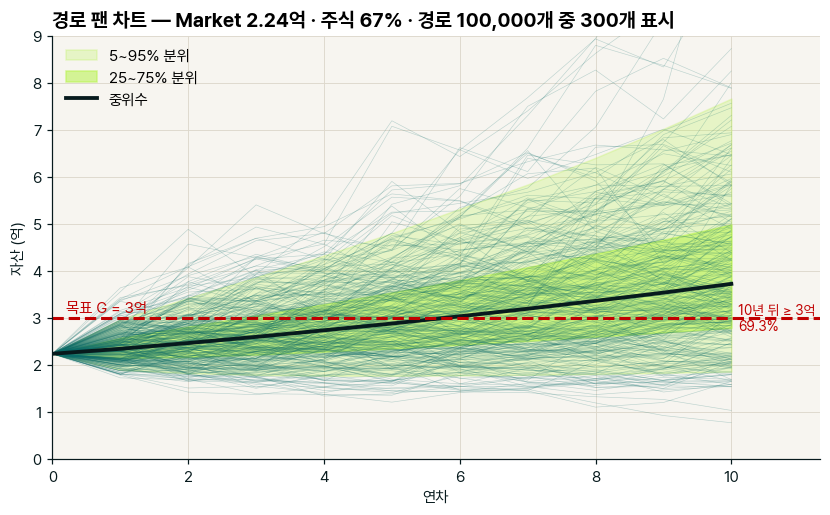

In [5]:
Wfan = run_fixed(2.24, W_MARKET, R)
yrs = np.arange(T + 1)
q = np.percentile(Wfan, [5, 25, 50, 75, 95], axis=0)
fig, ax = plt.subplots(figsize=(9, 5))
for i in range(300):
    ax.plot(yrs, Wfan[i], color=TEAL, lw=0.4, alpha=0.25)
ax.fill_between(yrs, q[0], q[4], color=LIME, alpha=0.25, label="5~95% 분위")
ax.fill_between(yrs, q[1], q[3], color=LIME, alpha=0.55, label="25~75% 분위")
ax.plot(yrs, q[2], color=INK, lw=2.5, label="중위수")
ax.axhline(3.0, color=RED, lw=2, ls="--"); ax.text(0.2, 3.1, "목표 G = 3억", color=RED, fontsize=10)
p_hit = np.mean(Wfan[:, -1] >= 3.0)
ax.text(10.1, 3.0, f"10년 뒤 ≥ 3억\n{p_hit:.1%}", color=RED, fontsize=9, va="center")
ax.set_ylim(0, 9); ax.set_xlim(0, 11.3)
ax.set_xlabel("연차"); ax.set_ylabel("자산 (억)")
ax.set_title(f"경로 팬 차트 — Market 2.24억 · 주식 67% · 경로 {N:,}개 중 300개 표시")
ax.legend(loc="upper left"); plt.show()

## 4. K 찾기 — 장난감 예: 경로 10개 (강의 45장)
10년 뒤 자산 = K × 성장 배수. 후보 K 2.0 · 2.2 · 2.4억마다 **같은 10개 경로**에서 3억 이상인 경로를 셉니다.

In [6]:
g10 = run_fixed(1.0, W_MARKET, R[:10])[:, -1]          # 경로 10개의 10년 성장 배수
LECT_G = [1.401, 1.472, 2.131, 2.282, 5.717, 2.492, 0.802, 1.963, 1.523, 0.924]
print(f"{'경로':>4s} {'성장 배수':>8s}   K=2.0   K=2.2   K=2.4")
for i, gi in enumerate(g10):
    cells_ = "".join(f"{K * gi:7.2f}{'✓' if K * gi >= 3 else ' '}" for K in (2.0, 2.2, 2.4))
    print(f"{i + 1:>4d} {gi:8.3f}  {cells_}")
    check(f"경로 {i + 1} 성장 배수", gi, LECT_G[i], 0.0005, ".3f")
hits = {K: int(np.sum(K * g10 >= 3.0)) for K in (2.0, 2.2, 2.4)}
print("성공 수:", {K: f"{h}/10 = {h * 10}%" for K, h in hits.items()})
K_toy = min(K for K, h in hits.items() if h / 10 >= 0.70)
print(f"→ 비율 ≥ 70%인 가장 작은 후보 K = {K_toy}억")
for K, lect in [(2.0, 6), (2.2, 8), (2.4, 8)]:
    check(f"장난감 K {K} 성공 수", hits[K], lect, 0.5, ".0f")
check("장난감 답 K", K_toy, 2.2, 1e-9, ".1f")

  경로    성장 배수   K=2.0   K=2.2   K=2.4
   1    1.401     2.80    3.08✓   3.36✓
✓ 경로 1 성장 배수: 계산 1.401 · 강의 1.401 (허용 ±0.0005)
   2    1.472     2.94    3.24✓   3.53✓
✓ 경로 2 성장 배수: 계산 1.472 · 강의 1.472 (허용 ±0.0005)
   3    2.131     4.26✓   4.69✓   5.11✓
✓ 경로 3 성장 배수: 계산 2.131 · 강의 2.131 (허용 ±0.0005)
   4    2.282     4.56✓   5.02✓   5.48✓
✓ 경로 4 성장 배수: 계산 2.282 · 강의 2.282 (허용 ±0.0005)
   5    5.717    11.43✓  12.58✓  13.72✓
✓ 경로 5 성장 배수: 계산 5.717 · 강의 5.717 (허용 ±0.0005)
   6    2.492     4.98✓   5.48✓   5.98✓
✓ 경로 6 성장 배수: 계산 2.492 · 강의 2.492 (허용 ±0.0005)
   7    0.802     1.60    1.76    1.92 
✓ 경로 7 성장 배수: 계산 0.802 · 강의 0.802 (허용 ±0.0005)
   8    1.963     3.93✓   4.32✓   4.71✓
✓ 경로 8 성장 배수: 계산 1.963 · 강의 1.963 (허용 ±0.0005)
   9    1.523     3.05✓   3.35✓   3.66✓
✓ 경로 9 성장 배수: 계산 1.523 · 강의 1.523 (허용 ±0.0005)
  10    0.924     1.85    2.03    2.22 
✓ 경로 10 성장 배수: 계산 0.924 · 강의 0.924 (허용 ±0.0005)
성공 수: {2.0: '6/10 = 60%', 2.2: '8/10 = 80%', 2.4: '8/10 = 80%'}
→ 비율 ≥ 70%인 가장 작은 후보 K = 2.

## 5. 같은 일을 100,000 경로로 — 이분법 (강의 45 · 50장)
이분법 = 후보 구간을 반씩 좁힌다. 성공 비율 ≥ p인 쪽이면 위를 줄이고, 아니면 아래를 올린다 — 60번이면 충분합니다.
닫힌 해(방법 1)는 2.24억, MC는 2.26억(차이는 닫힌 해가 연속 재조정, MC는 매년 되돌림이라 생기는 것).

In [7]:
def k_min(G, p, growth, n_iter=60):
    """같은 경로의 성장 배수(= W_T / K)에서 달성 비율 ≥ p인 최소 K — 이분법"""
    lo, hi = 0.0, G * 10
    for _ in range(n_iter):
        mid = (lo + hi) / 2
        if np.mean(mid * growth >= G) >= p: hi = mid
        else: lo = mid
    return hi

def k_closed(G, z, w):
    m = r + w * lam - 0.5 * w * w * sig * sig; s = w * sig
    return G * math.exp(-T * (m - z * s / math.sqrt(T)))

gM = run_fixed(1.0, W_MARKET, R)[:, -1]
K_mc = k_min(3.0, 0.70, gM)
K_cf = k_closed(3.0, 0.524, W_MARKET)
print(f"Market: MC K = {K_mc:.3f}억 (N {N:,}) · 닫힌 해 K = {K_cf:.3f}억 · 닫힌 해 K에서 센 확률 {np.mean(K_cf * gM >= 3):.2%}")
check("MC K (억)", K_mc, 2.26, 0.005, ".2f"); check("닫힌 해 K (억)", K_cf, 2.24, 0.005, ".2f")

Market: MC K = 2.258억 (N 100,000) · 닫힌 해 K = 2.244억 · 닫힌 해 K에서 센 확률 69.51%
✓ MC K (억): 계산 2.26 · 강의 2.26 (허용 ±0.005)
✓ 닫힌 해 K (억): 계산 2.24 · 강의 2.24 (허용 ±0.005)


**그래프 — K에 따른 성공 비율.** 같은 경로에서 K를 키우면 성공 비율은 계단식으로 올라갑니다. p = 70% 선과 처음 만나는 K가 답입니다.

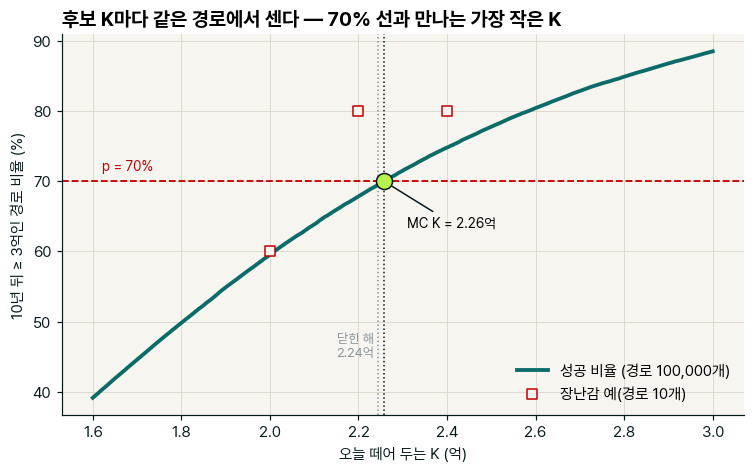

In [8]:
Ks = np.linspace(1.6, 3.0, 400)
gs_sorted = np.sort(gM)
rate = 1 - np.searchsorted(gs_sorted, 3.0 / Ks, side="left") / len(gs_sorted)   # = mean(K × g ≥ 3)
fig, ax = plt.subplots()
ax.plot(Ks, rate * 100, color=TEAL, lw=2.5, label=f"성공 비율 (경로 {N:,}개)")
ax.axhline(70, color=RED, ls="--", lw=1.2); ax.text(1.62, 71.5, "p = 70%", color=RED, fontsize=9)
ax.axvline(K_mc, color=INK, lw=1, ls=":"); ax.axvline(K_cf, color=GRAY, lw=1, ls=":")
ax.scatter([K_mc], [70], s=110, color=LIME, edgecolor=INK, zorder=5)
ax.annotate(f"MC K = {K_mc:.2f}억", (K_mc, 70), xytext=(15, -30), textcoords="offset points", fontsize=9, arrowprops=dict(arrowstyle="-", color=INK))
ax.text(K_cf - 0.01, 45, f"닫힌 해\n{K_cf:.2f}억", ha="right", fontsize=8.5, color=GRAY)
for K, h in hits.items():
    ax.scatter(K, h * 10, marker="s", s=50, color=IVORY, edgecolor=RED, zorder=5)
ax.scatter([], [], marker="s", color=IVORY, edgecolor=RED, label="장난감 예(경로 10개)")
ax.set_xlabel("오늘 떼어 두는 K (억)"); ax.set_ylabel("10년 뒤 ≥ 3억인 경로 비율 (%)")
ax.set_title("후보 K마다 같은 경로에서 센다 — 70% 선과 만나는 가장 작은 K")
ax.legend(loc="lower right"); plt.show()

## 6. 다수결은 틀린다 — 코드로 확인 (강의 46장)
✗ 틀린 방법: 경로마다 가장 좋은 비중(그 경로에서 K가 가장 덜 드는 것)을 고르고 가장 많이 뽑힌 것을 택한다.
미래 경로를 안 뒤 고르는 **사후 최적**이라 실행할 수 없고, 오른 경로는 주식 100% · 내린 경로는 GHP 100%로 갈립니다.

In [9]:
w_grid = np.round(np.linspace(0, 1, 21), 2)
G_all = np.column_stack([run_fixed(1.0, w, R)[:, -1] for w in w_grid])   # 경로 × 후보 비중의 성장 배수
best_w = w_grid[G_all.argmax(axis=1)]                                      # 경로마다 '사후 최적' 비중
share0, share1 = np.mean(best_w == 0.0), np.mean(best_w == 1.0)
print(f"경로마다 고른 최적 비중: GHP 100%(w 0) {share0:.1%} · 주식 100%(w 1) {share1:.1%} · 그 사이 {1 - share0 - share1:.1%}")
vote = w_grid[np.bincount((best_w * 20).round().astype(int), minlength=21).argmax()]
print(f"다수결로 뽑힌 비중 w = {vote:.0%}")
# 사후 최적은 실행할 수 없다 — 경로마다 다른 비중을 '미리' 알 수 없다. 그렇게 세면 K가 실제보다 싸 보인다:
K_hind = k_min(3.0, 0.70, G_all.max(axis=1))
print(f"사후 최적(경로마다 최고 비중)으로 센 70% K = {K_hind:.3f}억  ← 미래를 알아야 가능한, 실제보다 싼 숫자")
# 올바른 방법: 후보 비중마다 같은 경로 전체로 70% K를 센다
K_by_w = np.array([k_min(3.0, 0.70, G_all[:, j]) for j in range(len(w_grid))])
j = K_by_w.argmin()
print(f"올바른 방법: 후보 비중마다 K를 세면 최소 K = {K_by_w[j]:.3f}억 (w {w_grid[j]:.0%}) · 다수결 w {vote:.0%}의 K = {K_by_w[list(w_grid).index(vote)]:.3f}억")
# 강의 문장 확인(숫자가 아니라 방향): 다수결은 끝점(주식 100%)을 고르고, 그 K는 올바른 최소 K보다 비싸며, 사후 최적 K는 실행 불가능하게 싸다
assert vote == 1.0 and K_by_w[-1] > K_by_w[j] and K_hind < K_by_w[j]
print(f"※ 양 끝이 {share0 + share1:.0%} — 매년 비중을 되돌리면 등락이 섞인 경로에서는 중간 비중이 가장 좋은 경우도 있어(약 {1 - share0 - share1:.0%}) 100%는 아니다")

경로마다 고른 최적 비중: GHP 100%(w 0) 18.7% · 주식 100%(w 1) 64.1% · 그 사이 17.3%
다수결로 뽑힌 비중 w = 100%
사후 최적(경로마다 최고 비중)으로 센 70% K = 2.247억  ← 미래를 알아야 가능한, 실제보다 싼 숫자
올바른 방법: 후보 비중마다 K를 세면 최소 K = 2.258억 (w 70%) · 다수결 w 100%의 K = 2.297억
※ 양 끝이 83% — 매년 비중을 되돌리면 등락이 섞인 경로에서는 중간 비중이 가장 좋은 경우도 있어(약 17%) 100%는 아니다


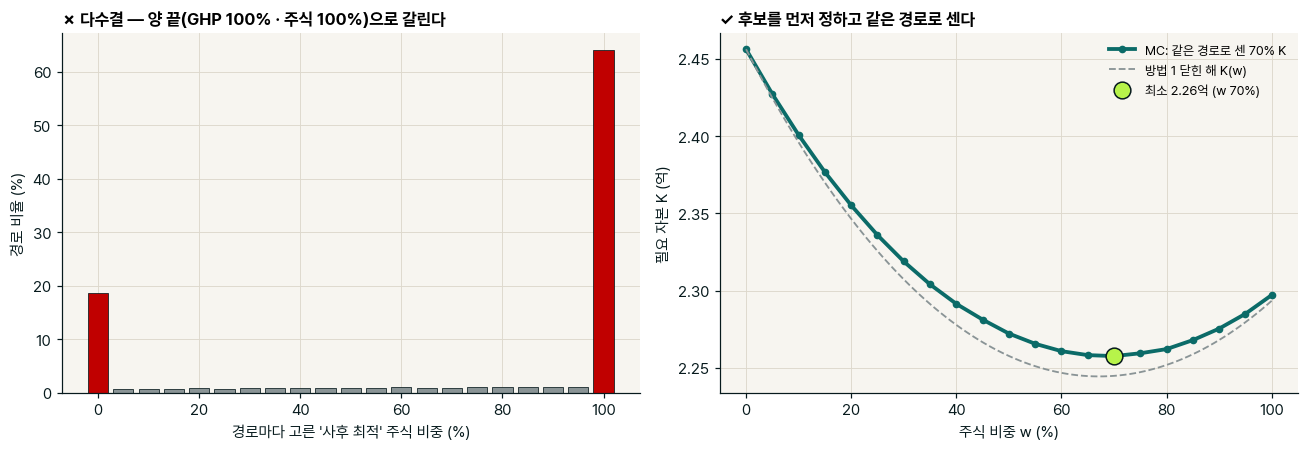

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.2))
cnt = np.bincount((best_w * 20).round().astype(int), minlength=21) / len(best_w) * 100
ax1.bar(w_grid * 100, cnt, width=4, color=[RED if c in (0, 20) else GRAY for c in range(21)], edgecolor=INK, lw=0.5)
ax1.set_xlabel("경로마다 고른 '사후 최적' 주식 비중 (%)"); ax1.set_ylabel("경로 비율 (%)")
ax1.set_title("✗ 다수결 — 양 끝(GHP 100% · 주식 100%)으로 갈린다", fontsize=11)
ax2.plot(w_grid * 100, K_by_w, color=TEAL, lw=2.5, marker="o", ms=4, label="MC: 같은 경로로 센 70% K")
ws_fine = np.linspace(0, 1, 101)
ax2.plot(ws_fine * 100, [k_closed(3.0, 0.524, w) for w in ws_fine], color=GRAY, lw=1.2, ls="--", label="방법 1 닫힌 해 K(w)")
ax2.scatter(w_grid[j] * 100, K_by_w[j], s=120, color=LIME, edgecolor=INK, zorder=5, label=f"최소 {K_by_w[j]:.2f}억 (w {w_grid[j]:.0%})")
ax2.set_xlabel("주식 비중 w (%)"); ax2.set_ylabel("필요 자본 K (억)")
ax2.set_title("✓ 후보를 먼저 정하고 같은 경로로 센다", fontsize=11); ax2.legend(fontsize=8.5)
fig.tight_layout(); plt.show()

## 7. 목표별로 나눠 더하면 (강의 46장 (i))
계좌를 나누면 목표별로 따로 → 4.91 + 2.26 + 1.97 = **9.14억**(방법 1의 9.13억과 0.01억 차이).

In [11]:
KS = k_closed(6.0, 1.645, 0.0)                                   # Safety: GHP뿐 — 변동성 0이라 식으로 확정
gA = run_fixed(1.0, 1.0, R)[:, -1]
KA = k_min(5.0, 0.30, gA)
print(f"Safety {KS:.2f} + Market {K_mc:.2f} + Aspirational {KA:.2f} = {KS + K_mc + KA:.2f}억")
check("Safety K", KS, 4.91, 0.005, ".2f"); check("Aspirational MC K", KA, 1.97, 0.005, ".2f")
check("나눈 계좌 합계 (억)", KS + K_mc + KA, 9.14, 0.005, ".2f")

Safety 4.91 + Market 2.26 + Aspirational 1.97 = 9.14억
✓ Safety K: 계산 4.91 · 강의 4.91 (허용 ±0.005)
✓ Aspirational MC K: 계산 1.97 · 강의 1.97 (허용 ±0.005)
✓ 나눈 계좌 합계 (억): 계산 9.14 · 강의 9.14 (허용 ±0.005)


## 8. 공통 난수 효과 (강의 54장 예 ③)
1만 경로 묶음을 바꿔 세면 K 2.26억이 70.63 · 69.90%로 흔들려 K 2.24억(69.96%)보다 낮게도 나옵니다.
같은 경로를 쓰면 같은 후보는 언제나 같은 비율, 큰 K는 언제나 같거나 높은 비율 — 후보 비교가 흔들리지 않습니다.

In [12]:
setA, setB = gM[:10_000], gM[10_000:20_000]
crn = {(K, nm): float(np.mean(K * s >= 3)) for K in (2.26, 2.24) for nm, s in [("A", setA), ("B", setB)]}
for K in (2.26, 2.24):
    print(f"K {K:.2f}억: 묶음 A {crn[(K, 'A')]:.2%} · 묶음 B {crn[(K, 'B')]:.2%}")
print(f"→ 묶음을 섞어 비교하면 K 2.26(묶음 B {crn[(2.26, 'B')]:.2%}) < K 2.24(묶음 A {crn[(2.24, 'A')]:.2%}): 큰 K가 더 나빠 보인다")
check("K 2.26 묶음 A (%)", 100 * crn[(2.26, "A")], 70.63, 0.005, ".2f")
check("K 2.26 묶음 B (%)", 100 * crn[(2.26, "B")], 69.90, 0.005, ".2f")
check("K 2.24 묶음 A (%)", 100 * crn[(2.24, "A")], 69.96, 0.005, ".2f")

K 2.26억: 묶음 A 70.63% · 묶음 B 69.90%
K 2.24억: 묶음 A 69.96% · 묶음 B 69.17%
→ 묶음을 섞어 비교하면 K 2.26(묶음 B 69.90%) < K 2.24(묶음 A 69.96%): 큰 K가 더 나빠 보인다
✓ K 2.26 묶음 A (%): 계산 70.63 · 강의 70.63 (허용 ±0.005)
✓ K 2.26 묶음 B (%): 계산 69.90 · 강의 69.90 (허용 ±0.005)
✓ K 2.24 묶음 A (%): 계산 69.96 · 강의 69.96 (허용 ±0.005)


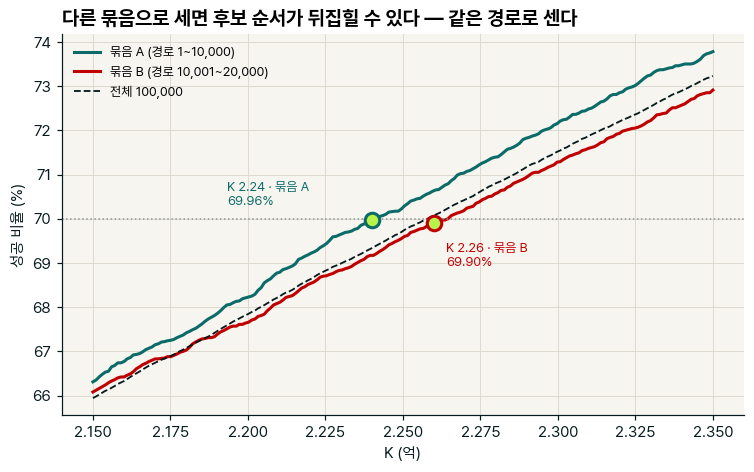

In [13]:
Kc = np.linspace(2.15, 2.35, 200)
rate_of = lambda s: [np.mean(k * s >= 3) * 100 for k in Kc]
fig, ax = plt.subplots()
ax.plot(Kc, rate_of(setA), color=TEAL, lw=2, label="묶음 A (경로 1~10,000)")
ax.plot(Kc, rate_of(setB), color=RED, lw=2, label="묶음 B (경로 10,001~20,000)")
ax.plot(Kc, rate_of(gM), color=INK, lw=1.2, ls="--", label=f"전체 {N:,}")
ax.axhline(70, color=GRAY, lw=1, ls=":")
for K, nm, c in [(2.26, "B", RED), (2.24, "A", TEAL)]:
    ax.scatter(K, crn[(K, nm)] * 100, s=90, color=LIME, edgecolor=c, zorder=5, lw=2)
    ax.annotate(f"K {K} · 묶음 {nm}\n{crn[(K, nm)]:.2%}", (K, crn[(K, nm)] * 100), xytext=(8, -28) if nm == "B" else (-95, 10),
                textcoords="offset points", fontsize=8.5, color=c)
ax.set_xlabel("K (억)"); ax.set_ylabel("성공 비율 (%)")
ax.set_title("다른 묶음으로 세면 후보 순서가 뒤집힐 수 있다 — 같은 경로로 센다"); ax.legend(loc="upper left", fontsize=8.5)
plt.show()

## 9. 그래프 — 표준오차와 N
이론선 √(p(1 − p)/N)과, 서로 다른 난수로 같은 실험(K 2.24억의 성공 비율)을 40번 반복해 잰 실제 흔들림을 비교합니다.
N을 100배 늘려야 오차가 10분의 1로 줍니다.

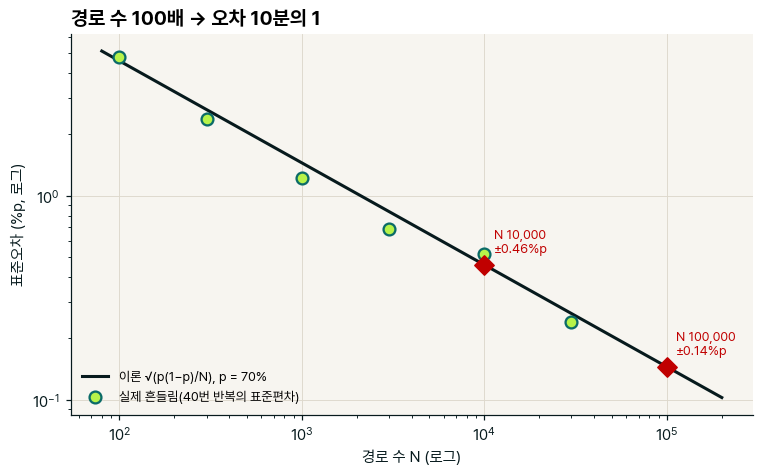

In [14]:
rng_se = np.random.default_rng(7)
Ns = [100, 300, 1_000, 3_000, 10_000] if FAST else [100, 300, 1_000, 3_000, 10_000, 30_000]
emp = []
for n in Ns:
    rates = [np.mean(2.24 * run_fixed(1.0, W_MARKET, stock_returns(rng_se, n))[:, -1] >= 3) for _ in range(40)]
    emp.append(np.std(rates))
nn = np.geomspace(80, 200_000, 200)
fig, ax = plt.subplots()
ax.plot(nn, [100 * se(0.7, n) for n in nn], color=INK, lw=2, label="이론 √(p(1−p)/N), p = 70%")
ax.scatter(Ns, [100 * e for e in emp], s=60, color=LIME, edgecolor=TEAL, zorder=5, lw=1.5, label="실제 흔들림(40번 반복의 표준편차)")
for n in (10_000, 100_000):
    ax.scatter(n, 100 * se(0.7, n), s=80, marker="D", color=RED, zorder=6)
    ax.annotate(f"N {n:,}\n±{100 * se(0.7, n):.2f}%p", (n, 100 * se(0.7, n)), xytext=(6, 8), textcoords="offset points", fontsize=8.5, color=RED)
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("경로 수 N (로그)"); ax.set_ylabel("표준오차 (%p, 로그)")
ax.set_title("경로 수 100배 → 오차 10분의 1"); ax.legend(loc="lower left", fontsize=8.5)
plt.show()

---
### 확인 결과 요약
이 노트북에서 강의본 숫자와 비교한 항목을 모아 봅니다. 모두 ✓이면 강의본 숫자를 그대로 재현한 것입니다.

In [15]:
# ── 확인 결과 요약 ──
n_ok = sum(ok for _, ok in CHECKS)
print(f"강의본 숫자 확인 {n_ok} / {len(CHECKS)} 통과" + (" — 빠른 모드라 일부 차이는 정상" if FAST else ""))
for label, ok in CHECKS:
    if not ok:
        print("  ✗", label)

강의본 숫자 확인 48 / 48 통과


---
## 바꿔 보기 (연습 문제)

1. 시드를 2026 → 7로 바꾸면(`SEED = 7`로 2절부터 다시) Market MC K는 얼마인가? 둘째 자리만 흔들리는가?
2. Market의 확률을 70% → 80%로 바꾸면 MC K(`k_min(3.0, 0.80, gM)`)와 닫힌 해(`k_closed(3.0, 0.8416, W_MARKET)`)는?
3. 경로 수를 1,000개로 줄여 K를 다시 세어 보라. 시드를 다섯 번 바꾸면 K가 얼마나 흔들리는가? 표준오차 식과 맞는가?

아래 빈 셀에서 직접 해 보세요. 위 셀의 함수를 그대로 불러 쓰면 됩니다.

In [16]:
# 여기에 직접 해 보기

In [17]:
# 여기에 직접 해 보기

In [18]:
# 여기에 직접 해 보기